In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def make_temperature_field(x, y):
    room_temperature = 26.0

    machine_heat = 6.0 * np.exp(
        -(((x - 7.5) ** 2) / 2.0 + ((y - 2.0) ** 2) / 1.5)
    )

    air_conditioner = 4.0 * np.exp(
        -(((x - 1.0) ** 2) / 3.0 + ((y - 6.5) ** 2) / 2.0)
    )

    airflow = 0.4 * np.sin(np.pi * x / 5) * np.cos(np.pi * y / 4)

    return room_temperature + machine_heat - air_conditioner + airflow

test_temperature = make_temperature_field(7.5, 2.0)
print(f"Temperature near the machine: {test_temperature:.1f} °C")

Temperature near the machine: 32.0 °C


In [11]:
x = np.linspace(0, 10, 200)
y = np.linspace(0, 8, 160)

In [12]:
X, Y = np.meshgrid(x, y)

In [13]:
temperature = make_temperature_field(X, Y)

print("Grid shape:", temperature.shape)
print("Minimum:", temperature.min())
print("Maximum:", temperature.max())

Grid shape: (160, 200)
Minimum: 22.086392153637643
Maximum: 32.003476271985704


In [14]:
print("Temperature field:\n", temperature)

Temperature field:
 [[26.         26.01262742 26.02524225 ... 25.99818861 26.00811568
  26.01831734]
 [26.         26.01261756 26.02522254 ... 26.00152755 26.01106403
  26.02091219]
 [26.         26.012588   26.02516345 ... 26.00527318 26.01435724
  26.02379418]
 ...
 [24.92336403 24.90020959 24.87778919 ... 25.97483654 25.987412
  26.        ]
 [24.9978307  24.97717797 24.95720763 ... 25.97477745 25.98738244
  26.        ]
 [25.06950537 25.05124198 25.03361125 ... 25.97475775 25.98737258
  26.        ]]


In [15]:
sensor_positions = np.array([
    [1, 1], [3, 2], [5, 1], [8, 1],
    [2, 4], [5, 4], [8, 4],
    [1, 7], [4, 7], [7, 7], [9, 7],
])

In [17]:
sensor_x = sensor_positions[:, 0]
sensor_y = sensor_positions[:, 1]

sensor_values = make_temperature_field(sensor_x, sensor_y)

In [18]:
rng = np.random.default_rng(42)
sensor_values += rng.normal(0, 0.15, len(sensor_positions))

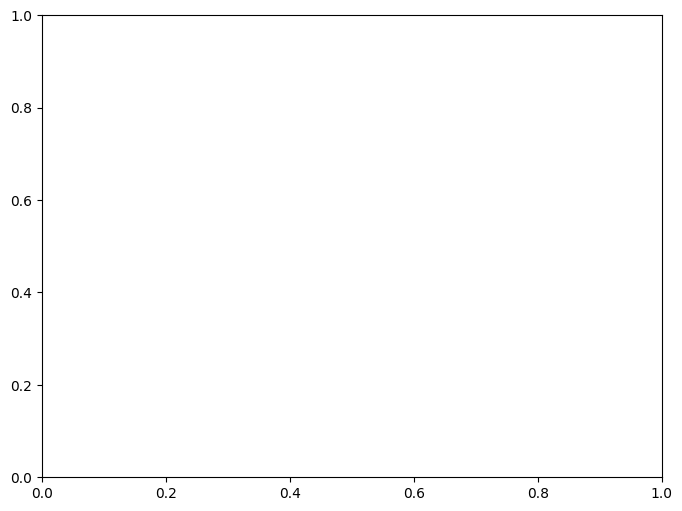

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

In [33]:
levels = np.arange(22, 34, 1)

lines = ax.contour(
    X,
    Y,
    temperature,
    levels=levels,
    colors="black",
    linewidths=0.8,
)

In [27]:
ax.clabel(lines, inline=True, fontsize=8, fmt="%.0f °C")

<a list of 12 text.Text objects>

In [28]:
ax.scatter(
    sensor_x,
    sensor_y,
    color="white",
    edgecolor="black",
    s=55,
    label="Temperature sensors",
)

In [30]:
ax.set(
    title="Temperature contour in a machine room",
    xlabel="Room width (m)",
    ylabel="Room height (m)",
    xlim=(0, 10),
    ylim=(0, 8),
    aspect="equal",
)
ax.legend()

In [31]:
plt.show()